# End-to-End MLOps Pipeline on AWS SageMaker AI

**Session Guide for College Students**

---

## What You'll Learn

In this notebook, we'll walk through the **complete lifecycle** of a machine learning project using **AWS SageMaker AI** — from raw data to a deployed, monitored model. This is what the industry calls **MLOps** (Machine Learning Operations).

### Pipeline Overview

```
┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌──────────────┐
│  1. Setup &  │───▶│ 2. Data      ───▶│ 3. Feature   │───▶│ 4. Model    │
│  Data Ingest │    │ Exploration  │    │ Engineering  │    │ Training     │
└──────────────┘    └──────────────┘    └──────────────┘    └──────────────┘
                                                                     │
┌──────────────┐    ┌──────────────┐    ┌──────────────┐             │
│  7. Monitor  │◀───│ 6. Batch     ◀──│ 5. Model     │◀──────────┘
│  & Retrain   │    │ Transform    │    │ Deployment   │
└──────────────┘    └──────────────┘    └──────────────┘
```

### Dataset
We'll use the **California Housing** dataset (a classic regression problem) via `sklearn`, which is commonly used in SageMaker tutorials and AWS examples.

**Goal:** Predict the **median house value** for California districts based on features like income, house age, and location.

---

## What is MLOps?

Think of **MLOps** as DevOps for Machine Learning. In a real company, building an ML model in a Jupyter notebook is only ~20% of the work. The other 80% involves:

| Challenge | MLOps Solution |
|---|---|
| "How do I train on large data?" | Managed training jobs (SageMaker Training) |
| "How do I serve predictions?" | Model endpoints (SageMaker Hosting) |
| "How do I version my models?" | Model Registry |
| "How do I automate retraining?" | SageMaker Pipelines |
| "How do I detect model drift?" | SageMaker Model Monitor |
| "How do I process data at scale?" | SageMaker Processing |

AWS SageMaker AI wraps all of these into a single managed platform. Let's dive in!

---
## Step 1: Environment Setup & Imports

###  Key Concept: SageMaker Session & Execution Role

Every SageMaker workflow starts with two things:
- **SageMaker Session** — Manages interactions with the SageMaker API and other AWS services (like S3).
- **Execution Role** — An IAM role that gives SageMaker permission to access your data in S3, spin up training instances, etc.

If you're running this in **SageMaker Studio** or a **SageMaker Notebook Instance**, these are automatically available.

In [1]:
# ============================================================
# STEP 1A: Install / upgrade dependencies (run once)
# ============================================================
# Uncomment the line below if you need to install/upgrade
# !pip install -U sagemaker boto3 pandas scikit-learn matplotlib seaborn --quiet

In [1]:
# ============================================================
# STEP 1B: Core imports
# ============================================================
import os
import json
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# AWS / SageMaker SDK
import boto3
import sagemaker
from sagemaker import get_execution_role
from sagemaker.session import Session

# Scikit-learn for data prep
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(f"SageMaker SDK version : {sagemaker.__version__}")
print(f"Boto3 version         : {boto3.__version__}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
SageMaker SDK version : 2.245.0
Boto3 version         : 1.37.3


In [2]:
# ============================================================
# STEP 1C: Initialize SageMaker session
# ============================================================
sagemaker_session = Session()
role = get_execution_role()               # IAM role for SageMaker
region = sagemaker_session.boto_region_name
bucket = sagemaker_session.default_bucket()  # SageMaker creates a default S3 bucket
prefix = "mlops-california-housing"         # S3 prefix (folder) for our project

print(f"Region          : {region}")
print(f"Role ARN        : {role}")
print(f"Default Bucket  : s3://{bucket}")
print(f"Project Prefix  : {prefix}")

Region          : us-east-1
Role ARN        : arn:aws:iam::113147284775:role/service-role/AmazonSageMaker-ExecutionRole-20260320T175733
Default Bucket  : s3://sagemaker-us-east-1-113147284775
Project Prefix  : mlops-california-housing


### Why S3?

SageMaker **does not** read data from your local notebook. Instead, training data must live in **Amazon S3** (Simple Storage Service), which is AWS's object storage.

Think of S3 like an infinite hard drive in the cloud. SageMaker training jobs pull data from S3, and output artifacts (trained models) back to S3.

```
Your Notebook  ──upload──▶  S3 Bucket  ──read──▶  SageMaker Training Job
                                                        │
                                                        ▼
                                              Model Artifact (.tar.gz)
                                              saved back to S3
```

---
## Step 2: Data Ingestion & Exploration (EDA)

###  Key Concept: Know Your Data Before You Model

The first rule of ML: **garbage in, garbage out**. We always start by understanding our dataset—its shape, distributions, missing values, and correlations.

In [4]:
# ============================================================
# STEP 2A: Load the California Housing dataset
# ============================================================
# This dataset is bundled with scikit-learn and is one of the
# standard datasets used in AWS SageMaker example notebooks.
#
# Features (8 numeric):
#   MedInc       – Median income in block group
#   HouseAge     – Median house age in block group
#   AveRooms     – Average number of rooms per household
#   AveBedrms    – Average number of bedrooms per household
#   Population   – Block group population
#   AveOccup     – Average number of household members
#   Latitude     – Block group latitude
#   Longitude    – Block group longitude
#
# Target:
#   MedHouseVal  – Median house value (in $100,000s)

housing = fetch_california_housing(as_frame=True)
df = housing.frame  # This gives us a nice pandas DataFrame

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {list(housing.feature_names)}")
print(f"Target  : MedHouseVal")
df.head()

Dataset shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target  : MedHouseVal


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# ============================================================
# STEP 2B: Quick statistical summary
# ============================================================
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [6]:
# ============================================================
# STEP 2C: Check for missing values
# ============================================================
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing: 0


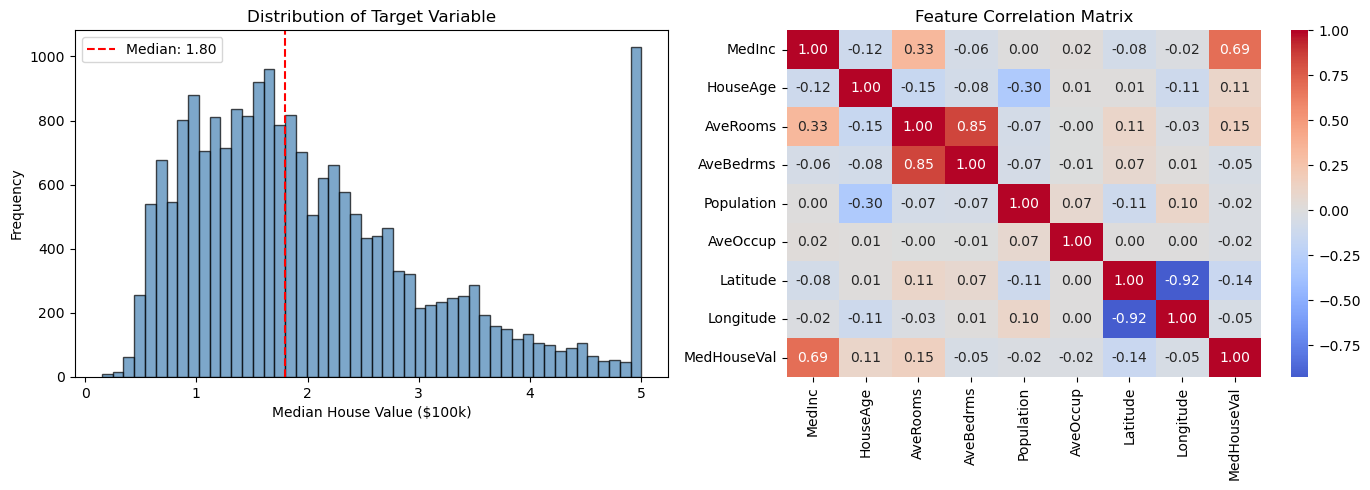

In [7]:
# ============================================================
# STEP 2D: Visualize target distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of target variable
axes[0].hist(df['MedHouseVal'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Target Variable')
axes[0].axvline(df['MedHouseVal'].median(), color='red', linestyle='--', label=f"Median: {df['MedHouseVal'].median():.2f}")
axes[0].legend()

# Correlation heatmap
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

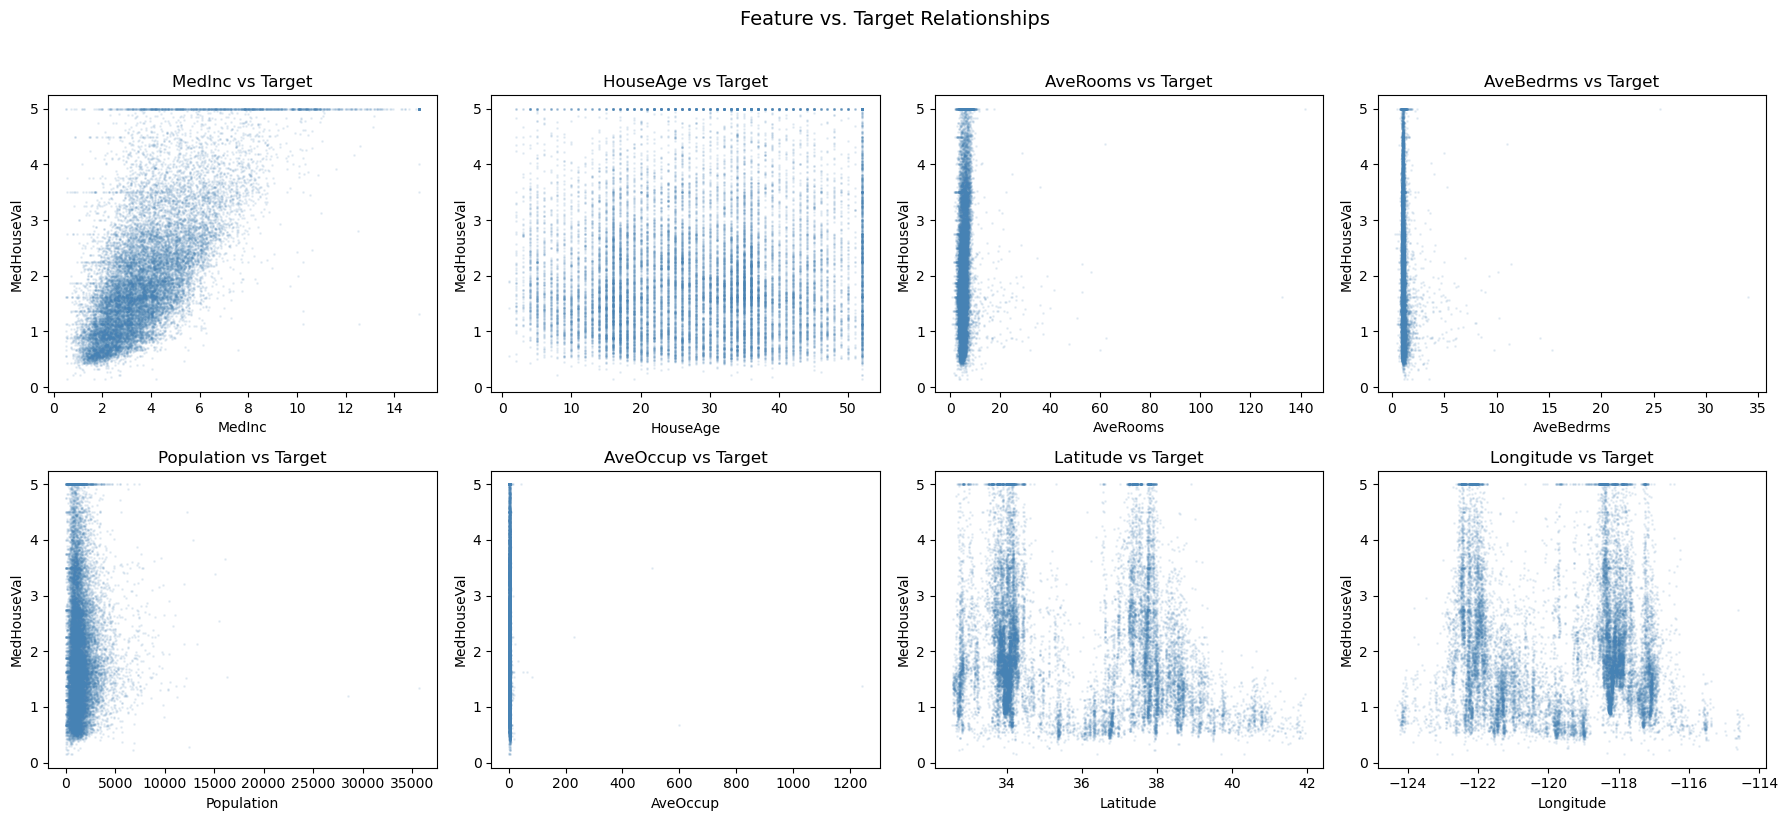

In [8]:
# ============================================================
# STEP 2E: Feature vs Target scatter plots
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for idx, col in enumerate(housing.feature_names):
    ax = axes[idx // 4, idx % 4]
    ax.scatter(df[col], df['MedHouseVal'], alpha=0.1, s=1, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'{col} vs Target')

plt.suptitle('Feature vs. Target Relationships', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### EDA Takeaways

From the exploration above, notice:

1. **MedInc** (median income) has the strongest positive correlation with house value — makes intuitive sense!
2. **Target is capped at 5.0** ($500k) — this is a known quirk of the dataset.
3. **No missing values** — that's convenient, but in real projects you'd often need imputation strategies.
4. **AveRooms and AveBedrms** are correlated with each other (multicollinearity) — something to keep in mind.
5. **Latitude/Longitude** encode geographic location — coastal areas tend to be more expensive.

---
## Step 3: Feature Engineering & Data Preparation

###  Key Concept: SageMaker Processing Jobs

In production MLOps, you don't run data preprocessing on your notebook. Instead, you use **SageMaker Processing Jobs**, which:
- Spin up dedicated compute instances for data processing
- Are reproducible and auditable
- Can handle terabytes of data
- Produce outputs that go directly to S3

For this tutorial, we'll first do preprocessing locally (so you can see the logic), then show how to wrap it in a SageMaker Processing Job.

```
                   SageMaker Processing Job
┌──────────────────────────────────────────────────┐
│  S3 Input  ──▶  Your Script (preprocessing.py)   │
│                      │                            │
│                      ▼                            │
│              train.csv, val.csv, test.csv         │
│                      │                            │
│                      ▼                            │
│               S3 Output                           │
└──────────────────────────────────────────────────┘
```

In [9]:
# ============================================================
# STEP 3A: Feature engineering
# ============================================================
# Let's create a few new features that might help the model.

df_feat = df.copy()

# Ratio features — sometimes ratios are more informative than raw values
df_feat['RoomsPerPerson'] = df_feat['AveRooms'] / df_feat['AveOccup']
df_feat['BedroomRatio']   = df_feat['AveBedrms'] / df_feat['AveRooms']
df_feat['PopPerHousehold'] = df_feat['Population'] / df_feat['AveOccup']

# Handle any infinite values from division
df_feat.replace([np.inf, -np.inf], np.nan, inplace=True)
df_feat.dropna(inplace=True)

print(f"Shape after feature engineering: {df_feat.shape}")
print(f"New features: RoomsPerPerson, BedroomRatio, PopPerHousehold")
df_feat.head()

Shape after feature engineering: (20640, 12)
New features: RoomsPerPerson, BedroomRatio, PopPerHousehold


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerPerson,BedroomRatio,PopPerHousehold
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591,126.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797,1138.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516,177.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458,219.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096,259.0


In [10]:
# ============================================================
# STEP 3B: Train / Validation / Test split
# ============================================================
# We need three splits:
#   - Train (70%)      → model learns from this
#   - Validation (15%) → used during training to tune hyperparams
#   - Test (15%)       → held out completely; used for final evaluation

target_col = 'MedHouseVal'
feature_cols = [c for c in df_feat.columns if c != target_col]

X = df_feat[feature_cols]
y = df_feat[target_col]

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Second split: split the 30% into 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train      : {X_train.shape[0]:,} rows")
print(f"Validation : {X_val.shape[0]:,} rows")
print(f"Test       : {X_test.shape[0]:,} rows")

Train      : 14,448 rows
Validation : 3,096 rows
Test       : 3,096 rows


In [11]:
# ============================================================
# STEP 3C: Feature scaling
# ============================================================
# StandardScaler: subtract mean, divide by std dev → mean=0, std=1
# IMPORTANT: fit ONLY on training data, then transform all splits.
# This prevents "data leakage" from val/test into training.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_val_scaled   = scaler.transform(X_val)          # transform only
X_test_scaled  = scaler.transform(X_test)         # transform only

print("After scaling (train set):")
print(f"  Mean ≈ {X_train_scaled.mean(axis=0).round(2)}")
print(f"  Std  ≈ {X_train_scaled.std(axis=0).round(2)}")

After scaling (train set):
  Mean ≈ [-0. -0.  0.  0.  0.  0. -0.  0.  0. -0.  0.]
  Std  ≈ [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Data Leakage — A Common Pitfall

Notice we called `scaler.fit_transform()` on training data only, then `scaler.transform()` on validation/test. If we had fit the scaler on the entire dataset, the model would have indirect knowledge of the test set's distribution — that's **data leakage**, and it makes your metrics unrealistically optimistic.

**Rule of thumb:** Anything you learn from data (statistics, vocabulary, feature mappings) must come from the training set only.

In [12]:
# ============================================================
# STEP 3D: Prepare CSVs in SageMaker's expected format
# ============================================================
# SageMaker's built-in XGBoost algorithm expects:
#   - CSV format with NO header
#   - Target variable in the FIRST column
#   - Features in remaining columns

def create_sagemaker_csv(X_scaled, y_series, filename):
    """Create CSV in SageMaker format: target first, no header."""
    combined = np.column_stack([y_series.values, X_scaled])
    np.savetxt(filename, combined, delimiter=',', fmt='%.6f')
    print(f"  Saved {filename} — shape {combined.shape}")

os.makedirs('data', exist_ok=True)

print("Creating SageMaker-format CSVs:")
create_sagemaker_csv(X_train_scaled, y_train, 'data/train.csv')
create_sagemaker_csv(X_val_scaled,   y_val,   'data/validation.csv')
create_sagemaker_csv(X_test_scaled,  y_test,  'data/test.csv')

Creating SageMaker-format CSVs:
  Saved data/train.csv — shape (14448, 12)
  Saved data/validation.csv — shape (3096, 12)
  Saved data/test.csv — shape (3096, 12)


In [13]:
# ============================================================
# STEP 3E: Upload data to S3
# ============================================================
# SageMaker training jobs read from S3, so we upload our CSVs there.

train_s3_uri = sagemaker_session.upload_data(
    path='data/train.csv',
    bucket=bucket,
    key_prefix=f'{prefix}/data/train'
)

val_s3_uri = sagemaker_session.upload_data(
    path='data/validation.csv',
    bucket=bucket,
    key_prefix=f'{prefix}/data/validation'
)

test_s3_uri = sagemaker_session.upload_data(
    path='data/test.csv',
    bucket=bucket,
    key_prefix=f'{prefix}/data/test'
)

print(f"Train data      : {train_s3_uri}")
print(f"Validation data : {val_s3_uri}")
print(f"Test data       : {test_s3_uri}")

Train data      : s3://sagemaker-us-east-1-113147284775/mlops-california-housing/data/train/train.csv
Validation data : s3://sagemaker-us-east-1-113147284775/mlops-california-housing/data/validation/validation.csv
Test data       : s3://sagemaker-us-east-1-113147284775/mlops-california-housing/data/test/test.csv


---
## Step 3.5 (Optional): SageMaker Processing Job

Below is how you'd wrap the same preprocessing logic into a **SageMaker Processing Job** for production use. This runs on a separate, dedicated instance.

**Why bother?** In real MLOps, your preprocessing must be:
- **Reproducible** — same code, same output every time
- **Scalable** — handle GBs/TBs of data
- **Part of the pipeline** — automatically triggered, not run manually

In [14]:
# ============================================================
# STEP 3.5A: Write the preprocessing script
# ============================================================
# This script would run INSIDE the Processing Job container.

preprocessing_script = '''
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

if __name__ == "__main__":
    # SageMaker Processing provides these paths automatically
    output_train = "/opt/ml/processing/output/train"
    output_val   = "/opt/ml/processing/output/validation"
    output_test  = "/opt/ml/processing/output/test"
    
    for d in [output_train, output_val, output_test]:
        os.makedirs(d, exist_ok=True)
    
    # Load data
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame
    
    # Feature engineering
    df["RoomsPerPerson"]  = df["AveRooms"] / df["AveOccup"]
    df["BedroomRatio"]    = df["AveBedrms"] / df["AveRooms"]
    df["PopPerHousehold"] = df["Population"] / df["AveOccup"]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    
    # Split
    target = "MedHouseVal"
    features = [c for c in df.columns if c != target]
    X_train, X_temp, y_train, y_temp = train_test_split(
        df[features], df[target], test_size=0.30, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42
    )
    
    # Scale
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)
    
    # Save: target first, no header
    for X_s, y_s, path in [
        (X_train_s, y_train, f"{output_train}/train.csv"),
        (X_val_s,   y_val,   f"{output_val}/validation.csv"),
        (X_test_s,  y_test,  f"{output_test}/test.csv"),
    ]:
        combined = np.column_stack([y_s.values, X_s])
        np.savetxt(path, combined, delimiter=",", fmt="%.6f")
    
    print("Preprocessing complete!")
'''

os.makedirs('scripts', exist_ok=True)
with open('scripts/preprocessing.py', 'w') as f:
    f.write(preprocessing_script)

print("Preprocessing script saved to scripts/preprocessing.py")

Preprocessing script saved to scripts/preprocessing.py


In [16]:
# ============================================================
# STEP 3.5B: Run the SageMaker Processing Job
# ============================================================
# NOTE: This will spin up an ml.m5.xlarge instance (~$0.23/hr).
# Uncomment to run. For the tutorial, we already uploaded data above.

from sagemaker.sklearn.processing import SKLearnProcessor
from sagemaker.processing import ProcessingOutput

sklearn_processor = SKLearnProcessor(
    framework_version='1.2-1',
    role=role,
    instance_type='ml.m5.xlarge',
    instance_count=1,
    base_job_name='housing-preprocess'
)

# Uncomment below to actually run the processing job:
# sklearn_processor.run(
#     code='scripts/preprocessing.py',
#     outputs=[
#         ProcessingOutput(output_name='train',      source='/opt/ml/processing/output/train'),
#         ProcessingOutput(output_name='validation', source='/opt/ml/processing/output/validation'),
#         ProcessingOutput(output_name='test',       source='/opt/ml/processing/output/test'),
#     ]
# )

print("Processing Job definition ready (uncomment .run() to execute).")

INFO:sagemaker:Creating processing-job with name housing-preprocess-2026-03-20-12-37-17-037


...........Preprocessing complete!

Processing Job definition ready (uncomment .run() to execute).


---
## Step 4: Model Training with SageMaker Built-in XGBoost

### Key Concept: SageMaker Training Jobs

Instead of training on your notebook instance (which might be a tiny machine), SageMaker spins up a **separate, powerful compute instance** just for training, then shuts it down when done. You only pay for the minutes used.

```
   Your Notebook                   SageMaker Training Job
   ┌──────────┐                   ┌────────────────────────────┐
   │ Estimator│──API call──▶      │ ml.m5.xlarge instance      │
   │ .fit()   │                   │                            │
   └──────────┘                   │ 1. Pull data from S3       │
                                  │ 2. Pull algorithm container│
                                  │ 3. Train the model         │
                                  │ 4. Save model.tar.gz to S3 │
                                  │ 5. Shut down               │
                                  └────────────────────────────┘
```

### Why XGBoost?
**XGBoost** (eXtreme Gradient Boosting) is one of the most popular ML algorithms for tabular data. It builds an ensemble of decision trees, where each new tree corrects the errors of the previous ones. SageMaker provides a highly optimized, distributed version as a built-in algorithm.

In [17]:
# ============================================================
# STEP 4A: Set up the XGBoost Estimator
# ============================================================
from sagemaker.inputs import TrainingInput

# Get the URI of the SageMaker-managed XGBoost container image
xgboost_container = sagemaker.image_uris.retrieve(
    framework='xgboost',
    region=region,
    version='1.7-1'    # Latest stable version
)
print(f"XGBoost container image: {xgboost_container}")

# Create the Estimator
xgb_estimator = sagemaker.estimator.Estimator(
    image_uri=xgboost_container,
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    output_path=f's3://{bucket}/{prefix}/models',
    sagemaker_session=sagemaker_session,
    base_job_name='housing-xgboost',
    
    # Enable SageMaker Experiments tracking (MLOps best practice)
    enable_sagemaker_metrics=True,
)

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


XGBoost container image: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1


In [18]:
# ============================================================
# STEP 4B: Set hyperparameters
# ============================================================
# These control HOW the model learns. Think of them as "knobs" to tune.

xgb_estimator.set_hyperparameters(
    objective='reg:squarederror',  # Regression task (minimize MSE)
    num_round=200,                 # Number of boosting rounds (trees)
    max_depth=5,                   # Max depth of each tree (controls complexity)
    eta=0.1,                       # Learning rate (smaller = more conservative)
    subsample=0.8,                 # Fraction of data used per tree (prevents overfitting)
    colsample_bytree=0.8,          # Fraction of features used per tree
    min_child_weight=3,            # Min samples in a leaf node
    gamma=0.1,                     # Min loss reduction for a split
    eval_metric='rmse',            # Metric to monitor during training
    early_stopping_rounds=10,      # Stop if no improvement for 10 rounds
)

print("Hyperparameters set!")
print(json.dumps(xgb_estimator.hyperparameters(), indent=2))

Hyperparameters set!
{
  "objective": "reg:squarederror",
  "num_round": 200,
  "max_depth": 5,
  "eta": 0.1,
  "subsample": 0.8,
  "colsample_bytree": 0.8,
  "min_child_weight": 3,
  "gamma": 0.1,
  "eval_metric": "rmse",
  "early_stopping_rounds": 10
}


### Understanding Key Hyperparameters

| Parameter | What it does | Too low | Too high |
|-----------|-------------|---------|----------|
| `num_round` | Number of trees | Underfitting | Overfitting (but early stopping helps) |
| `max_depth` | Tree complexity | Underfitting | Overfitting, slow training |
| `eta` (learning rate) | Step size per tree | Very slow convergence | Overfitting, unstable |
| `subsample` | Data sampling ratio | High variance | More prone to overfitting |
| `early_stopping_rounds` | Patience for stopping | Stops too early | Wastes compute |

In [ ]:
# ============================================================
# STEP 4C: Define data channels and launch training
# ============================================================
# SageMaker uses "channels" to pass data into training jobs.
# The channel name (e.g., 'train', 'validation') tells the
# algorithm which data is for training vs. evaluation.

train_input = TrainingInput(
    s3_data=train_s3_uri,
    content_type='text/csv'
)

validation_input = TrainingInput(
    s3_data=val_s3_uri,
    content_type='text/csv'
)

# Launch the training job!
# This will take ~3-5 minutes (instance startup + training)
print("Starting training job... (this takes a few minutes)")
xgb_estimator.fit(
    inputs={
        'train': train_input,
        'validation': validation_input
    },
    wait=True,   # Block until training is complete
    logs='All'   # Show training logs in real time
)

print(f"\nTraining complete!")
print(f"Model artifact: {xgb_estimator.model_data}")

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: housing-xgboost-2026-03-20-12-42-51-015


Starting training job... (this takes a few minutes)
2026-03-20 12:42:52 Starting - Starting the training job...
2026-03-20 12:43:06 Starting - Preparing the instances for training...
2026-03-20 12:43:55 Downloading - Downloading the training image......
2026-03-20 12:44:56 Training - Training image download completed. Training in progress.
2026-03-20 12:44:56 Uploading - Uploading generated training model./miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-20 12:44:50.954 ip-10-2-246-237.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-03-20 12:44:51.024 ip-10-2-246-237.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-03-20:12:44:51

---
## Step 4.5: Hyperparameter Tuning (Automatic)

### Key Concept: SageMaker Automatic Model Tuning (HPO)

Manually picking hyperparameters is tedious. SageMaker can **automatically search** for the best combination using Bayesian Optimization.

Think of it this way: instead of training 1 model, SageMaker launches **multiple training jobs in parallel**, each with different hyperparameter values. It learns from previous results to focus on promising regions of the search space.

In [20]:
# ============================================================
# STEP 4.5: Hyperparameter Tuning Job
# ============================================================
from sagemaker.tuner import (
    IntegerParameter,
    ContinuousParameter,
    HyperparameterTuner
)

# Define the ranges to search over
hyperparameter_ranges = {
    'max_depth':        IntegerParameter(3, 10),
    'eta':              ContinuousParameter(0.01, 0.3),
    'subsample':        ContinuousParameter(0.5, 1.0),
    'colsample_bytree': ContinuousParameter(0.5, 1.0),
    'min_child_weight': IntegerParameter(1, 10),
}

# Define the objective: minimize validation RMSE
objective_metric_name = 'validation:rmse'

tuner = HyperparameterTuner(
    estimator=xgb_estimator,
    objective_metric_name=objective_metric_name,
    objective_type='Minimize',
    hyperparameter_ranges=hyperparameter_ranges,
    max_jobs=10,            # Total number of training jobs to launch
    max_parallel_jobs=2,    # How many to run at the same time
    strategy='Bayesian',    # Use Bayesian optimization
    base_tuning_job_name='housing-hpo'
)

# Uncomment to run (costs ~$2-3 for 10 jobs on ml.m5.xlarge):
# tuner.fit(inputs={'train': train_input, 'validation': validation_input})
# print(f"Best training job: {tuner.best_training_job()}")

print("HPO Tuner configured with Bayesian strategy.")
print(f"  Search space: {len(hyperparameter_ranges)} parameters")
print(f"  Budget: 10 jobs (2 parallel)")
print("  Uncomment tuner.fit() to launch.")

HPO Tuner configured with Bayesian strategy.
  Search space: 5 parameters
  Budget: 10 jobs (2 parallel)
  Uncomment tuner.fit() to launch.


---
## Step 5: Model Evaluation

### Key Concept: Batch Transform

SageMaker **Batch Transform** lets you run predictions on a large dataset *without deploying a persistent endpoint*. It's perfect for:
- Evaluating on the test set
- Running predictions on a large batch of data
- One-off prediction tasks

```
S3 (test.csv) ──▶ Batch Transform Job ──▶ S3 (predictions.csv)
                   (spins up, predicts,
                    shuts down)
```

In [ ]:
# ============================================================
# STEP 5A: Run Batch Transform on test data
# ============================================================
# First, prepare test data WITHOUT the target column for inference
test_data_no_target = np.loadtxt('data/test.csv', delimiter=',')
test_features_only  = test_data_no_target[:, 1:]  # Remove first column (target)
test_actuals        = test_data_no_target[:, 0]    # Keep targets for evaluation

os.makedirs('data/test_features', exist_ok=True)
np.savetxt('data/test_features/test_features.csv', test_features_only, delimiter=',', fmt='%.6f')

test_features_s3 = sagemaker_session.upload_data(
    path='data/test_features/test_features.csv',
    bucket=bucket,
    key_prefix=f'{prefix}/data/test_features'
)

# Create and run the Batch Transform job
transformer = xgb_estimator.transformer(
    instance_count=1,
    instance_type='ml.m5.xlarge',
    output_path=f's3://{bucket}/{prefix}/batch-predictions',
    accept='text/csv'
)

print("Starting Batch Transform job...")
transformer.transform(
    data=test_features_s3,
    content_type='text/csv',
    split_type='Line'
)
transformer.wait()
print("Batch Transform complete!")

INFO:sagemaker:Creating model with name: housing-xgboost-2026-03-20-12-47-41-373
INFO:sagemaker:Creating transform job with name: housing-xgboost-2026-03-20-12-47-42-140


Starting Batch Transform job...
................................/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-20:12:52:58:INFO] No GPUs detected (normal if no gpus installed)
[2026-03-20:12:52:58:INFO] No GPUs detected (normal if no gpus installed)
[2026-03-20:12:52:58:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log

In [22]:
# ============================================================
# STEP 5B: Download predictions and evaluate
# ============================================================
import boto3
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Download predictions from S3
s3_client = boto3.client('s3')
predictions_key = f'{prefix}/batch-predictions/test_features.csv.out'

s3_client.download_file(
    Bucket=bucket,
    Key=predictions_key,
    Filename='data/predictions.csv'
)

predictions = np.loadtxt('data/predictions.csv', delimiter=',')

# Compute metrics
rmse = np.sqrt(mean_squared_error(test_actuals, predictions))
mae  = mean_absolute_error(test_actuals, predictions)
r2   = r2_score(test_actuals, predictions)

print("═" * 50)
print("         MODEL EVALUATION RESULTS")
print("═" * 50)
print(f"  RMSE  : {rmse:.4f}  (Root Mean Squared Error)")
print(f"  MAE   : {mae:.4f}  (Mean Absolute Error)")
print(f"  R²    : {r2:.4f}  (Coefficient of Determination)")
print("═" * 50)
print(f"\nInterpretation:")
print(f"  On average, predictions are off by ~${mae*100000:,.0f}")
print(f"  The model explains {r2*100:.1f}% of the variance in house values.")

══════════════════════════════════════════════════
         MODEL EVALUATION RESULTS
══════════════════════════════════════════════════
  RMSE  : 0.4478  (Root Mean Squared Error)
  MAE   : 0.3039  (Mean Absolute Error)
  R²    : 0.8484  (Coefficient of Determination)
══════════════════════════════════════════════════

Interpretation:
  On average, predictions are off by ~$30,388
  The model explains 84.8% of the variance in house values.


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:7                                                                                    │
│                                                                                                  │
│    4 fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                             │
│    5                                                                                             │
│    6 # Scatter: Predicted vs Actual                                                              │
│ ❱  7 axes[0].scatter(test_actuals, predictions, alpha=0.3, s=5, color='steelblue')               │
│    8 axes[0].plot([0, 5.5], [0, 5.5], 'r--', linewidth=2, label='Perfect predictions')           │
│    9 axes[0].set_xlabel('Actual House Value ($100k)')                                            │
│   10 axes[0].set_ylabel('Predicted House Value ($100k)')                                         │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'test_actuals' is not defined

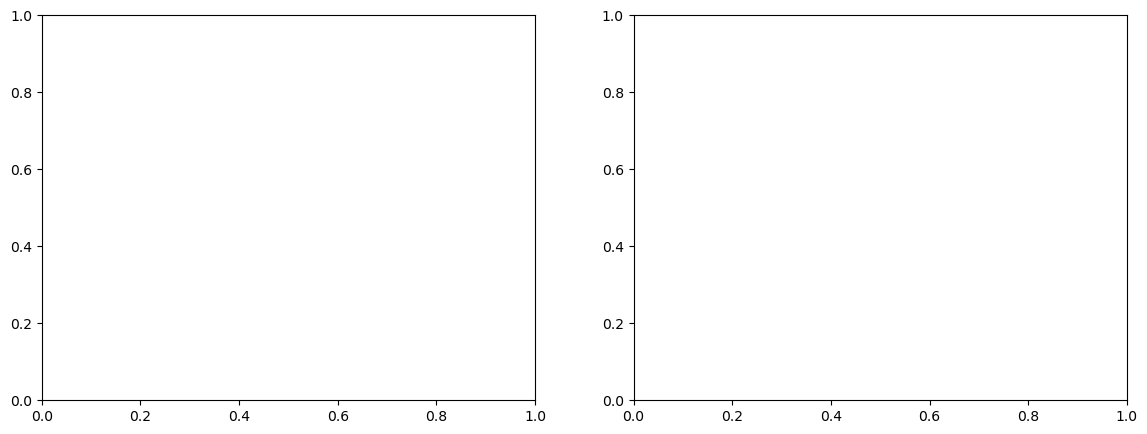

In [3]:
# ============================================================
# STEP 5C: Visualization — Predicted vs Actual
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Predicted vs Actual
axes[0].scatter(test_actuals, predictions, alpha=0.3, s=5, color='steelblue')
axes[0].plot([0, 5.5], [0, 5.5], 'r--', linewidth=2, label='Perfect predictions')
axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title(f'Predicted vs Actual  (R² = {r2:.3f})')
axes[0].legend()

# Residuals distribution
residuals = predictions - test_actuals
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Predicted - Actual)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

### How to Read These Plots

**Left plot (Predicted vs Actual):** Points close to the red dashed line = good predictions. The dashed line represents perfect accuracy where predicted equals actual.

**Right plot (Residuals):** The residuals should be centered around 0 (no systematic bias) and roughly bell-shaped. A skewed distribution would suggest the model consistently over- or under-predicts.

---
## Step 6: Model Registry

### Key Concept: Why a Model Registry?

Imagine your team trains dozens of models over time. The **Model Registry** is a central catalog that tracks:
- Which model versions exist
- Their performance metrics
- Their approval status (PendingApproval → Approved → Deployed)
- Lineage: what data and code produced them

```
Model Registry: "HousingPriceModel"
├── v1  [Approved]   — RMSE: 0.55,  deployed to prod
├── v2  [Rejected]   — RMSE: 0.62,  regression detected
├── v3  [Approved]   — RMSE: 0.48,  waiting for deployment
└── v4  [Pending]    — RMSE: 0.47,  needs review
```

In [ ]:
# ============================================================
# STEP 6A: Register the model in SageMaker Model Registry
# ============================================================
from sagemaker.model_metrics import MetricsSource, ModelMetrics

model_package_group_name = 'CaliforniaHousingModelGroup'

# Create the model package group (like a folder for model versions)
sm_client = boto3.client('sagemaker')

try:
    sm_client.create_model_package_group(
        ModelPackageGroupName=model_package_group_name,
        ModelPackageGroupDescription='XGBoost models for California Housing price prediction'
    )
    print(f"Created Model Package Group: {model_package_group_name}")
except sm_client.exceptions.ClientError as e:
    if 'already exists' in str(e):
        print(f"Model Package Group '{model_package_group_name}' already exists.")
    else:
        raise

In [ ]:
# ============================================================
# STEP 6B: Save evaluation metrics to S3 (for the registry)
# ============================================================
import json

evaluation_report = {
    'regression_metrics': {
        'rmse': {'value': rmse, 'standard_deviation': 'NaN'},
        'mae':  {'value': mae,  'standard_deviation': 'NaN'},
        'r2':   {'value': r2,   'standard_deviation': 'NaN'},
    }
}

os.makedirs('evaluation', exist_ok=True)
with open('evaluation/evaluation.json', 'w') as f:
    json.dump(evaluation_report, f, indent=2)

eval_s3_uri = sagemaker_session.upload_data(
    path='evaluation/evaluation.json',
    bucket=bucket,
    key_prefix=f'{prefix}/evaluation'
)
print(f"Evaluation report uploaded: {eval_s3_uri}")

In [ ]:
# ============================================================
# STEP 6C: Register the model version
# ============================================================
model_metrics = ModelMetrics(
    model_statistics=MetricsSource(
        s3_uri=eval_s3_uri,
        content_type='application/json'
    )
)

model_package = xgb_estimator.register(
    model_package_group_name=model_package_group_name,
    inference_instances=['ml.m5.xlarge', 'ml.t2.medium'],
    transform_instances=['ml.m5.xlarge'],
    content_types=['text/csv'],
    response_types=['text/csv'],
    model_metrics=model_metrics,
    approval_status='PendingManualApproval',  # Requires human review
    description=f'XGBoost v1 — RMSE={rmse:.4f}, R2={r2:.4f}'
)

model_package_arn = model_package.model_package_arn
print(f"Model registered!")
print(f"   ARN: {model_package_arn}")
print(f"   Status: PendingManualApproval")

In [ ]:
# ============================================================
# STEP 6D: Approve the model (simulating human review)
# ============================================================
# In a real MLOps workflow, a data scientist or ML engineer
# would review the metrics and then approve or reject.

sm_client.update_model_package(
    ModelPackageArn=model_package_arn,
    ModelApprovalStatus='Approved'
)
print(f"Model approved for deployment!")

---
## Step 7: Model Deployment (Real-Time Endpoint)

### Key Concept: SageMaker Endpoints

A SageMaker **Endpoint** is a hosted REST API that serves predictions in real time. When you call `.deploy()`, SageMaker:

1. Provisions an EC2 instance
2. Loads the model artifact from S3
3. Starts a web server that listens for prediction requests
4. Keeps it running 24/7 until you delete it

```
Your App ──HTTP POST──▶ SageMaker Endpoint ──▶ Prediction
          (features)     (model loaded)          (house value)
```

**Cost warning:** Endpoints are billed per hour even when idle. Always delete endpoints after testing!

In [ ]:
# ============================================================
# STEP 7A: Deploy the model as a real-time endpoint
# ============================================================
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import CSVDeserializer

endpoint_name = f'housing-endpoint-{datetime.datetime.now().strftime("%Y%m%d-%H%M%S")}'

print(f"Deploying endpoint: {endpoint_name}")
print("This takes ~5-8 minutes...")

predictor = xgb_estimator.deploy(
    initial_instance_count=1,
    instance_type='ml.t2.medium',       # Small instance for demo
    endpoint_name=endpoint_name,
    serializer=CSVSerializer(),          # Send CSV data
    deserializer=CSVDeserializer(),      # Receive CSV response
)

print(f"\nEndpoint deployed: {endpoint_name}")

In [ ]:
# ============================================================
# STEP 7B: Test the endpoint with sample predictions
# ============================================================
# Send a few test samples to the endpoint

sample_data = X_test_scaled[:5]  # First 5 test samples
sample_actuals = y_test.values[:5]

print("Sending 5 test samples to endpoint...\n")
print(f"{'Sample':<8} {'Actual':>10} {'Predicted':>10} {'Error':>10}")
print("-" * 42)

for i in range(5):
    # Convert numpy array to CSV string for the endpoint
    payload = ','.join([f'{x:.6f}' for x in sample_data[i]])
    response = predictor.predict(payload)
    
    # Parse the response
    predicted = float(response[0][0])
    actual = sample_actuals[i]
    error = abs(predicted - actual)
    
    print(f"  {i+1:<6} ${actual*100:>8,.0f}k  ${predicted*100:>8,.0f}k  ${error*100:>8,.0f}k")

### Real-Time vs Batch Inference — When to Use Which?

| Use Case | Method | Example |
|----------|--------|---------|
| User clicks "Estimate Price" on a website | **Real-time endpoint** | Zillow-style price estimator |
| Score 1 million leads overnight | **Batch Transform** | CRM lead scoring |
| Mobile app needs sub-second response | **Real-time endpoint** | Fraud detection |
| Generate monthly report predictions | **Batch Transform** | Insurance risk assessment |

---
## Step 8: Model Monitoring

### Key Concept: Data Drift & Model Drift

Your model was trained on data from a specific time period. Over time, the real world changes:
- **Data drift:** The input features change distribution, a customer behavior shift. (e.g., post-pandemic housing boom)
- **Concept drift:** The relationship between features and target changes (e.g., evolving spam email content)

**SageMaker Model Monitor** watches your endpoint and alerts you when the incoming data starts looking different from your training data.

```
Live Traffic ──▶ Endpoint ──▶ Predictions
      │                           │
      ▼                           ▼
  Data Capture               Model Monitor
  (logs every request)       (compares to baseline)
      │                           │
      └──── Drift Detected? ──────┘
                  │
                  ▼
          Alert / Retrain
```

In [ ]:
# ============================================================
# STEP 8A: Enable Data Capture on the endpoint
# ============================================================
from sagemaker.model_monitor import DataCaptureConfig

data_capture_config = DataCaptureConfig(
    enable_capture=True,
    sampling_percentage=100,  # Capture 100% of requests (use lower % in production)
    destination_s3_uri=f's3://{bucket}/{prefix}/data-capture',
    capture_options=['Input', 'Output'],  # Capture both request and response
)

# Update the endpoint with data capture
predictor.update_data_capture_config(data_capture_config)
print(" Data capture enabled on the endpoint.")
print(f"   Captures saved to: s3://{bucket}/{prefix}/data-capture")

In [ ]:
# ============================================================
# STEP 8B: Create a baseline for monitoring
# ============================================================
# The baseline captures the statistical properties of the training
# data (mean, std, distribution, etc.). The monitor will compare
# live traffic against this baseline.

from sagemaker.model_monitor import DefaultModelMonitor
from sagemaker.model_monitor.dataset_format import DatasetFormat

# Create a CSV with headers for the baseline
baseline_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_cols
)
baseline_df.to_csv('data/baseline.csv', index=False)

baseline_s3_uri = sagemaker_session.upload_data(
    path='data/baseline.csv',
    bucket=bucket,
    key_prefix=f'{prefix}/baseline'
)

my_monitor = DefaultModelMonitor(
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    volume_size_in_gb=20,
    max_runtime_in_seconds=3600,
)

print("Generating baseline statistics...")
print("(Uncomment below to run — takes ~5 mins)")

# Uncomment to run:
# my_monitor.suggest_baseline(
#     baseline_dataset=baseline_s3_uri,
#     dataset_format=DatasetFormat.csv(header=True),
#     output_s3_uri=f's3://{bucket}/{prefix}/baseline-results',
#     wait=True
# )
# print("Baseline created!")

In [ ]:
# ============================================================
# STEP 8C: Schedule monitoring (runs hourly / daily)
# ============================================================
from sagemaker.model_monitor import CronExpressionGenerator

# This would schedule a monitoring job to run every hour
# Uncomment to activate:

# my_monitor.create_monitoring_schedule(
#     monitor_schedule_name='housing-model-monitor-schedule',
#     endpoint_input=endpoint_name,
#     output_s3_uri=f's3://{bucket}/{prefix}/monitoring-reports',
#     statistics=my_monitor.baseline_statistics(),
#     constraints=my_monitor.suggested_constraints(),
#     schedule_cron_expression=CronExpressionGenerator.hourly(),
# )

print("Model Monitor schedule definition ready.")
print("When activated, it will:")
print("  1. Collect data captured from the endpoint")
print("  2. Compare feature distributions to baseline")
print("  3. Flag any drift violations")
print("  4. Generate a report in S3")

---
## Step 9: SageMaker Pipelines (Automated MLOps)

### Key Concept: ML Pipelines

Everything we did above was manual — we ran each step one at a time. In production, you want this automated. **SageMaker Pipelines** lets you define the entire workflow as a DAG (Directed Acyclic Graph) that can be triggered automatically.

```
┌────────────┐     ┌────────────┐     ┌────────────┐     ┌──────────┐
│ Processing │────▶│  Training  │────▶│ Evaluation │────▶│ Register │
│  (prep)    │     │ (XGBoost)  │     │  (metrics) │     │ (if good)│
└────────────┘     └────────────┘     └────────────┘     └──────────┘
                                                              │
                                            RMSE < threshold? │
                                              ┌───────┬───────┘
                                              ▼       ▼
                                            YES      NO
                                              │       │
                                          Register   STOP
```

This is the **crown jewel of MLOps**: CI/CD for ML models.

In [ ]:
# ============================================================
# STEP 9A: Define Pipeline Parameters
# ============================================================
from sagemaker.workflow.parameters import (
    ParameterString,
    ParameterFloat,
    ParameterInteger
)

# These are configurable parameters — you can change them
# without modifying the pipeline code.

processing_instance_type = ParameterString(
    name='ProcessingInstanceType',
    default_value='ml.m5.xlarge'
)

training_instance_type = ParameterString(
    name='TrainingInstanceType',
    default_value='ml.m5.xlarge'
)

model_approval_status = ParameterString(
    name='ModelApprovalStatus',
    default_value='PendingManualApproval'
)

# Threshold for automatic model approval
rmse_threshold = ParameterFloat(
    name='RMSEThreshold',
    default_value=0.6
)

print("Pipeline parameters defined.")

In [ ]:
# ============================================================
# STEP 9B: Write the evaluation script
# ============================================================
# This script runs inside a SageMaker Processing Job container.
#
# IMPORTANT: We use SKLearnProcessor, which has scikit-learn
# pre-installed but NOT xgboost. So we pip-install xgboost
# at the top of the script before importing it.
#
# Alternative approaches:
#   - Use sagemaker.processing.FrameworkProcessor with a
#     requirements.txt containing 'xgboost'
#   - Use a custom Docker container with xgboost baked in
#   - Use ScriptProcessor with SageMaker's XGBoost image

evaluation_script = '''
import subprocess
import sys

# The SKLearnProcessor container does NOT have xgboost pre-installed.
# We install it at runtime before importing it.
subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])

import json
import os
import tarfile
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

if __name__ == "__main__":
    # Load model artifact (SageMaker saves it as a .tar.gz in S3)
    model_dir = "/opt/ml/processing/model"
    model_tar = os.path.join(model_dir, "model.tar.gz")
    with tarfile.open(model_tar, "r:gz") as tar:
        tar.extractall(path=model_dir)
    
    model = xgb.Booster()
    model.load_model(os.path.join(model_dir, "xgboost-model"))
    
    # Load test data
    test_data = np.loadtxt("/opt/ml/processing/test/test.csv", delimiter=",")
    y_test = test_data[:, 0]
    X_test = test_data[:, 1:]
    
    # Predict
    dtest = xgb.DMatrix(X_test)
    predictions = model.predict(dtest)
    
    # Evaluate
    rmse = float(np.sqrt(mean_squared_error(y_test, predictions)))
    mae  = float(mean_absolute_error(y_test, predictions))
    r2   = float(r2_score(y_test, predictions))
    
    report = {
        "regression_metrics": {
            "rmse": {"value": rmse},
            "mae":  {"value": mae},
            "r2":   {"value": r2},
        }
    }
    
    output_dir = "/opt/ml/processing/evaluation"
    os.makedirs(output_dir, exist_ok=True)
    with open(os.path.join(output_dir, "evaluation.json"), "w") as f:
        json.dump(report, f, indent=2)
    
    print(f"Evaluation: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")
'''

with open('scripts/evaluation.py', 'w') as f:
    f.write(evaluation_script)
print("Evaluation script saved.")

In [ ]:
# ============================================================
# STEP 9C: Build the SageMaker Pipeline
# ============================================================
from sagemaker.workflow.steps import ProcessingStep, TrainingStep
from sagemaker.workflow.step_collections import RegisterModel
from sagemaker.workflow.conditions import ConditionLessThanOrEqualTo
from sagemaker.workflow.condition_step import ConditionStep
from sagemaker.workflow.functions import JsonGet
from sagemaker.workflow.properties import PropertyFile
from sagemaker.workflow.pipeline import Pipeline
from sagemaker.processing import ProcessingInput, ProcessingOutput
from sagemaker.sklearn.processing import SKLearnProcessor

# --- Step 1: Processing ---
sklearn_processor = SKLearnProcessor(
    framework_version='1.2-1',
    role=role,
    instance_type=processing_instance_type,
    instance_count=1,
    base_job_name='pipeline-preprocess'
)

processing_step = ProcessingStep(
    name='PreprocessData',
    processor=sklearn_processor,
    code='scripts/preprocessing.py',
    outputs=[
        ProcessingOutput(output_name='train',      source='/opt/ml/processing/output/train'),
        ProcessingOutput(output_name='validation',  source='/opt/ml/processing/output/validation'),
        ProcessingOutput(output_name='test',        source='/opt/ml/processing/output/test'),
    ]
)

# --- Step 2: Training ---
training_step = TrainingStep(
    name='TrainXGBoost',
    estimator=xgb_estimator,
    inputs={
        'train': TrainingInput(
            s3_data=processing_step.properties.ProcessingOutputConfig
                .Outputs['train'].S3Output.S3Uri,
            content_type='text/csv'
        ),
        'validation': TrainingInput(
            s3_data=processing_step.properties.ProcessingOutputConfig
                .Outputs['validation'].S3Output.S3Uri,
            content_type='text/csv'
        ),
    }
)

# --- Step 3: Evaluation ---
eval_processor = SKLearnProcessor(
    framework_version='1.2-1',
    role=role,
    instance_type=processing_instance_type,
    instance_count=1,
    base_job_name='pipeline-evaluate'
)

evaluation_report = PropertyFile(
    name='EvaluationReport',
    output_name='evaluation',
    path='evaluation.json'
)

evaluation_step = ProcessingStep(
    name='EvaluateModel',
    processor=eval_processor,
    code='scripts/evaluation.py',
    inputs=[
        ProcessingInput(
            source=training_step.properties.ModelArtifacts.S3ModelArtifacts,
            destination='/opt/ml/processing/model'
        ),
        ProcessingInput(
            source=processing_step.properties.ProcessingOutputConfig
                .Outputs['test'].S3Output.S3Uri,
            destination='/opt/ml/processing/test'
        ),
    ],
    outputs=[
        ProcessingOutput(output_name='evaluation', source='/opt/ml/processing/evaluation'),
    ],
    property_files=[evaluation_report],
)

# --- Step 4: Conditional Registration ---
register_step = RegisterModel(
    name='RegisterModel',
    estimator=xgb_estimator,
    model_data=training_step.properties.ModelArtifacts.S3ModelArtifacts,
    content_types=['text/csv'],
    response_types=['text/csv'],
    inference_instances=['ml.t2.medium', 'ml.m5.xlarge'],
    transform_instances=['ml.m5.xlarge'],
    model_package_group_name=model_package_group_name,
    approval_status=model_approval_status,
)

# Only register if RMSE is below threshold
condition = ConditionLessThanOrEqualTo(
    left=JsonGet(
        step_name=evaluation_step.name,
        property_file=evaluation_report,
        json_path='regression_metrics.rmse.value'
    ),
    right=rmse_threshold
)

condition_step = ConditionStep(
    name='CheckRMSEThreshold',
    conditions=[condition],
    if_steps=[register_step],
    else_steps=[],  # Do nothing if RMSE is too high
)

print("Pipeline steps defined:")
print("  1. PreprocessData")
print("  2. TrainXGBoost")
print("  3. EvaluateModel")
print("  4. CheckRMSEThreshold → RegisterModel (if RMSE ≤ threshold)")

In [ ]:
# ============================================================
# STEP 9D: Create and (optionally) start the pipeline
# ============================================================
pipeline = Pipeline(
    name='CaliforniaHousingMLOpsPipeline',
    parameters=[
        processing_instance_type,
        training_instance_type,
        model_approval_status,
        rmse_threshold,
    ],
    steps=[
        processing_step,
        training_step,
        evaluation_step,
        condition_step,
    ],
    sagemaker_session=sagemaker_session
)

# Validate the pipeline definition
pipeline_definition = json.loads(pipeline.definition())
print(f"Pipeline '{pipeline.name}' validated successfully!")
print(f"Steps: {[step['Name'] for step in pipeline_definition['Steps']]}")

# Uncomment to create and start the pipeline:
# pipeline.upsert(role_arn=role)
# execution = pipeline.start()
# print(f"Pipeline execution started: {execution.arn}")
# execution.wait()  # Wait for completion

---
## Step 10: Clean Up Resources

### IMPORTANT: Avoid Unnecessary AWS Charges

SageMaker endpoints and some other resources are billed continuously. **Always clean up after your session!**

In [ ]:
# ============================================================
# STEP 10: Clean up all resources
# ============================================================

# 1. Delete the real-time endpoint (MOST IMPORTANT — billed per hour)
try:
    predictor.delete_endpoint()
    print(f" Endpoint '{endpoint_name}' deleted.")
except Exception as e:
    print(f" Could not delete endpoint: {e}")

# 2. Delete the model
try:
    predictor.delete_model()
    print(" Model deleted.")
except Exception as e:
    print(f" Could not delete model: {e}")

# 3. Optionally delete the pipeline
# pipeline.delete()

# 4. Optionally delete S3 data
# s3 = boto3.resource('s3')
# bucket_resource = s3.Bucket(bucket)
# bucket_resource.objects.filter(Prefix=prefix).delete()

print("\n🧹 Cleanup complete!")
print("   Remember to also stop/delete your SageMaker notebook instance if done.")

---
## Summary: What We Covered

Here's a recap of every SageMaker AI service we used and why:

| Step | SageMaker Service | Purpose |
|------|------------------|---------|
| Setup | SageMaker Session, IAM Role | Authentication & S3 integration |
| Data Prep | SageMaker Processing | Scalable, reproducible preprocessing |
| Training | SageMaker Training (Built-in XGBoost) | Managed training on dedicated instances |
| Tuning | SageMaker Hyperparameter Tuning | Automated hyperparameter search |
| Evaluation | SageMaker Batch Transform | Offline batch predictions |
| Versioning | SageMaker Model Registry | Track, version, and approve models |
| Deployment | SageMaker Endpoints | Real-time inference REST API |
| Monitoring | SageMaker Model Monitor | Detect data/model drift |
| Automation | SageMaker Pipelines | End-to-end CI/CD for ML |

### What to Explore Next

- **SageMaker Feature Store** — Centralized feature management for teams
- **SageMaker Clarify** — Bias detection and model explainability
- **SageMaker Experiments** — Track and compare ML experiments
- **SageMaker Debugger** — Real-time training debugging and profiling
- **SageMaker Ground Truth** — Data labeling service
- **Bring Your Own Container (BYOC)** — Use custom Docker images for training

### Useful Links

- [SageMaker Developer Guide](https://docs.aws.amazon.com/sagemaker/latest/dg/whatis.html)
- [SageMaker Python SDK Docs](https://sagemaker.readthedocs.io/)
- [AWS MLOps Whitepaper](https://docs.aws.amazon.com/whitepapers/latest/ml-best-practices/ml-best-practices.html)
- [SageMaker Example Notebooks (GitHub)](https://github.com/aws/amazon-sagemaker-examples)

---
*Notebook created for educational purposes. All SageMaker resources should be cleaned up after the session to avoid charges.*